# **ANÁLISIS DE LOS DATOS**


## **0. Librerías**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, regexp_replace, when, mean, count, desc, round, sum, variance, stddev, year
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## **1. Descarga del datase**

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

#Download
path = kagglehub.dataset_download("mysarahmadbhat/airbnb-listings-reviews")

Using Colab cache for faster access to the 'airbnb-listings-reviews' dataset.


## **2. Creación de la sesión de Spark**
Es necesario especificar la codificación para que Spark no lea el dataset como strings. Mediante `df_raw.printSchema()` comprobamos que los datos se han cargado correctamente.

In [ ]:
spark = SparkSession.builder \
    .appName("AirbnbAnalisis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

df_raw = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("encoding", "UTF-8") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .option("quote", "\"") \
    .option("ignoreLeadingWhiteSpace", "true") \
    .option("ignoreTrailingWhiteSpace", "true") \
    .csv("/kaggle/input/airbnb-listings-reviews/Airbnb Data/Listings.csv")

print(f"Total listings loaded: {df_raw.count():,}")
df_raw.printSchema()

Total listings loaded: 279,712
root
 |-- listing_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_since: date (nullable = true)
 |-- host_location: string (nullable = true)
 |-- host_response_time: string (nullable = true)
 |-- host_response_rate: double (nullable = true)
 |-- host_acceptance_rate: double (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_total_listings_count: integer (nullable = true)
 |-- host_has_profile_pic: string (nullable = true)
 |-- host_identity_verified: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- district: string (nullable = true)
 |-- city: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- property_type: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- accommodates: integer (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- amenities: strin

## **3. Consultas analíticas**

### **3.1. ¿Cómo cambia el precio medio por noche según el tipo de alojamiento y el barrio?**
**Objetivo:** Identificar diferencias relevantes de precio en función de ubicación y tipología.

**Utilidad:** Permite detectar zonas populares, oportunidades de inversión y estrategias para nuevos hosts.

In [ ]:
# Seleccionamos las columnas en las que estamos interesados.
df = df_raw.select(
    "city",
    "neighbourhood",
    "property_type",
    "price"
)
# Eliminamos filas con valores faltantes o NaNs.
df = df.na.drop(subset=["price", "neighbourhood", "property_type", "city"])

# Limpiamos la columna "price" de simbolos que no sean números.
df = df.withColumn("price_clean",
                   regexp_replace(col("price"), "[^0-9.]", "").cast("double")) \
       .drop("price") \
       .withColumnRenamed("price_clean", "price")

# Filtramos outliers (percentil 99).
price_99 = df.stat.approxQuantile("price", [0.99], 0.01)[0]
df = df.filter(col("price") <= price_99 * 1.5)

# Comprobamos cuanto ha cambiado el dataset.
print(f"Listings after cleaning: {df.count():,}")

No parece haber outliers.

In [ ]:
# Escogemos la ciudad más popular (París) para realizar el análisis.
ciudad = df.groupBy("city").count().orderBy(desc("count")).first()["city"]
df_ciudad = df.filter(col("city") == ciudad)

# Media de precio por barrio Parisino.
media_price_x_neighbourhood = (df_ciudad
    .groupBy("neighbourhood")
    .agg(mean("price").alias("media_price"),
         count("*").alias("listings"))
    .orderBy(desc("media_price"))
)
print("Los diez barrios parisinos más caros son: ")
media_price_x_neighbourhood.show(10)

# Media de precio por tipo de alojamiento.

media_price_x_property = (df_ciudad
    .groupBy("property_type")
    .agg(mean("price").alias("media_price"),
         count("*").alias("listings"))
    .filter(col("listings") >= 20)  # Solamente propiedades con una incidencia razonable
    .orderBy(desc("media_price"))
)

print("Los diez tipos de propiedades más caros son: ")
media_price_x_property.show(10)

# Heatmap: promedio de precio por "neighbourhood" × "property_type".
heatmap_df = (df_ciudad
    .groupBy("neighbourhood", "property_type")
    .agg(mean("price").alias("media_price"),
         count("*").alias("count"))
    .filter(col("count") >= 5)  # Evita convinaciones infrecuentes
)

Los diez barrios parisinos más caros son: 
+--------------+------------------+--------+
| neighbourhood|       media_price|listings|
+--------------+------------------+--------+
|        Elysee|210.53676470588235|    1768|
|        Louvre| 175.3799715909091|    1408|
|         Passy|161.14463452566096|    3215|
|Palais-Bourbon| 156.8565782044043|    1771|
|    Luxembourg|155.63863863863864|    1998|
|        Bourse|149.49680073126143|    2188|
|Hotel-de-Ville|144.47210953346857|    1972|
|        Temple|138.44682296975876|    2943|
|      Pantheon|122.66214953271027|    2140|
|         Opera|119.03864428254673|    3157|
+--------------+------------------+--------+
only showing top 10 rows

Los diez tipos de propiedades más caros son: 
+--------------------+------------------+--------+
|       property_type|       media_price|listings|
+--------------------+------------------+--------+
|  Room in aparthotel| 373.4938271604938|      81|
|Entire serviced a...| 296.7885714285714|     175|


#### **3.1.2. Visualización**

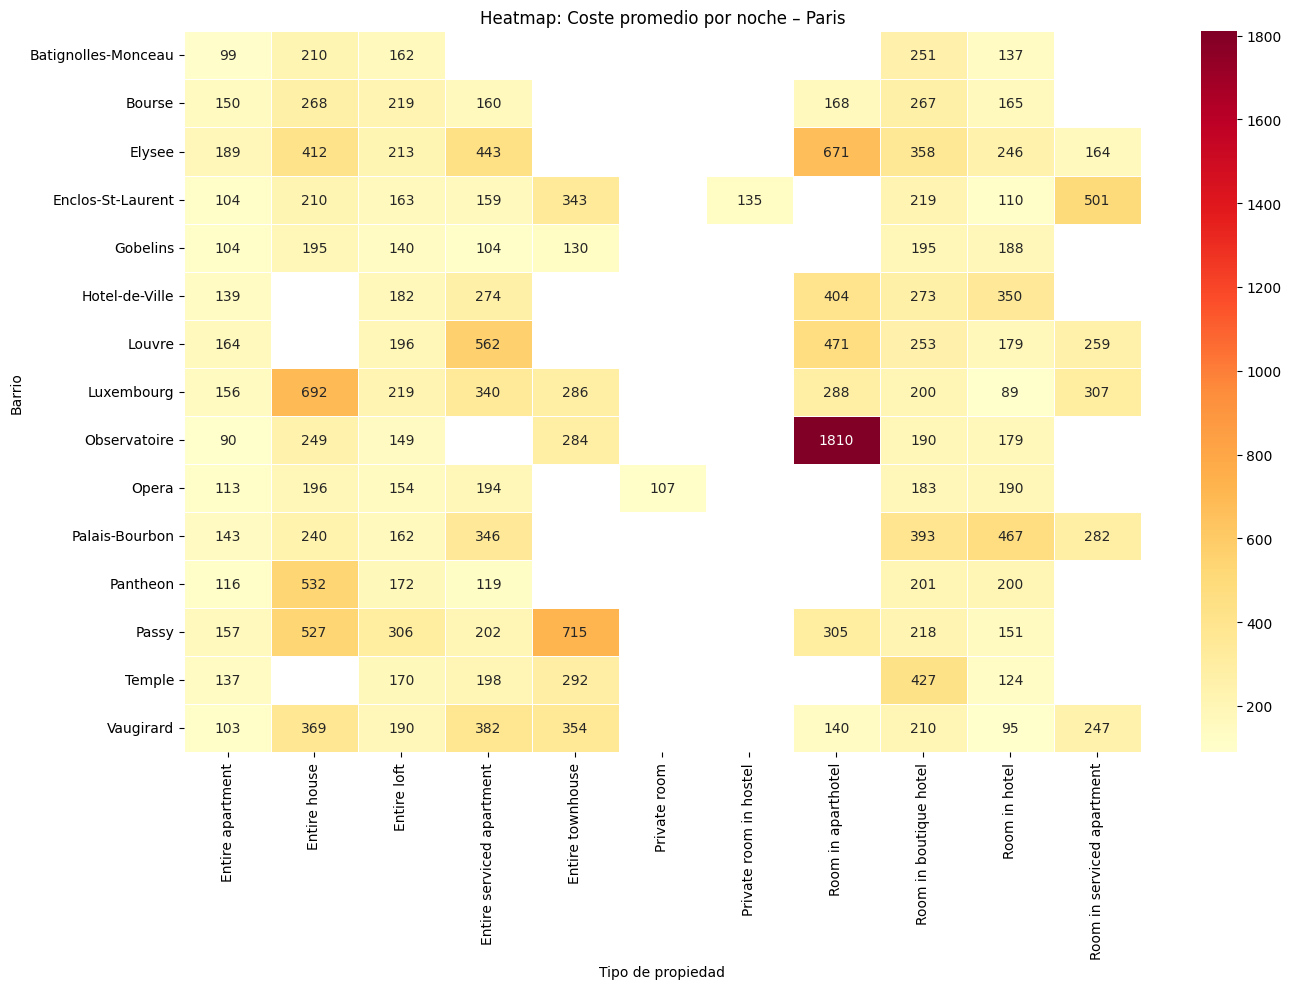

In [ ]:
pdf_neigh = media_price_x_neighbourhood.limit(20).toPandas()
pdf_prop  = media_price_x_property.toPandas()

pdf_pivot = heatmap_df.toPandas()
top_neigh = pdf_neigh.head(15)["neighbourhood"].tolist()
top_prop  = pdf_prop.head(12)["property_type"].tolist()

heatmap_data = pdf_pivot[
    pdf_pivot["neighbourhood"].isin(top_neigh) &
    pdf_pivot["property_type"].isin(top_prop)
].pivot(index="neighbourhood", columns="property_type", values="media_price")

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5)
plt.title(f"Heatmap: Coste promedio por noche – {ciudad}")
plt.ylabel("Barrio")
plt.xlabel("Tipo de propiedad")
plt.tight_layout()
plt.show()

La visualización mediante heatmap permite orientarse dentro de la matriz barrio-tipo de propiedad, para rapidamente encontrar aquellas convinaciones con un precio por noche mayor.

Este mapa podría orientar tanto a los turistas, a la hora de escoger mejores precio para un mismo barrio o alojamiento, o incluso a los inversores inmobiliarios que busquen oportunidades de inversión. En particular, salta a la vista que la convinación mejor valorada son las _abitaciones en apartahoteles_ en el barrio _Observatoire_. Así mismo, se aprecia como en ciertos barrios no se pueden encontrar algunos de los tipos de propiedades.

###**3.2. ¿Qué relación existe entre la valoración media (review_scores_rating) y el precio?**
**Objetivo:** Evaluar si precios más altos están asociados a mejores valoraciones.

**Utilidad:** Ayuda a hosts a decidir si mejorar servicios aumenta la disposición a pagar.

In [ ]:
# Limpieza
df = df_raw.select(
    col("price").cast("double"),
    col("review_scores_rating").cast("double")
).dropna()

# Filtramos outliers (percentil 99).
price_99 = df.stat.approxQuantile("price", [0.99], 0.01)[0]
df = df.filter(col("price") <= price_99 * 1.5)

# Ejecución de la correlación
corr = df.stat.corr("price", "review_scores_rating")
print("Correlación entre el precio y la valoración promedio:", corr)

Correlación entre el precio y la valoración promedio: 0.015047699005412245


#### **3.2.2. Visualización**

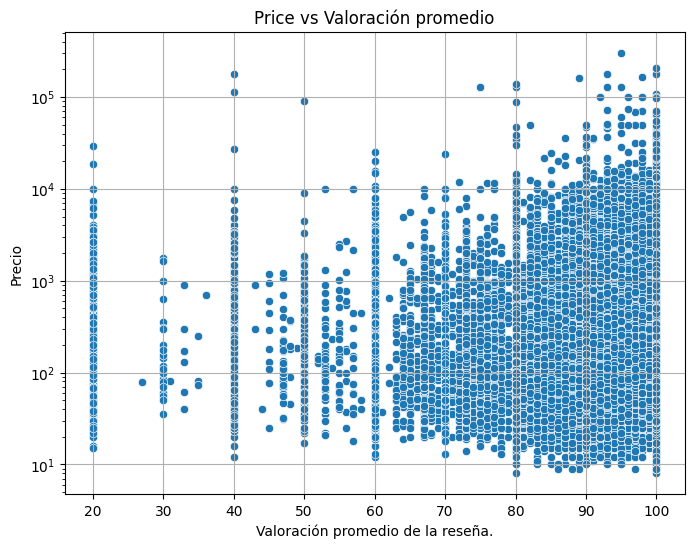

In [ ]:
pdf = df.toPandas()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pdf,
    x="review_scores_rating",
    y="price",
)

plt.xlabel("Valoración promedio de la reseña.")
plt.ylabel("Precio")
plt.title("Precio vs Valoración promedio")
plt.grid(True)
plt.show()

Tal y como se advertía en la ejecución del análisis, las valoraciones y el precio no tienen correlación. Esto indica que los arrendatarios ajustan sus expectativas al precio por noche, y reseñan en consecuencia.

Sin embargo, esta visualización nos permite ver que los usuarios tienden a votar numeros redondos, ya que los puntos se agrupan entorno a los múltiplos de diez. Además, los valores más extremos del precio obtienen muy buenas calificaciones, pudiendo indicar que los outliers más lujosos si son valorados positivamente (al ser atípicos no contribuyen a la correlación).

###**3.3. ¿Qué barrios presentan mayor concentración de anuncios en comparación con el total de la ciudad?**
**Objetivo:** Medir qué zonas acumulan proporcionalmente más anuncios dentro del total del mercado Airbnb de la ciudad.

**Utilidad:** Permite identificar zonas con mayor actividad turística o donde los hosts se concentran, lo cual es útil para estudios de saturación, planificación urbana o posicionamiento estratégico para nuevos anfitriones.

In [ ]:
# Escogemos la ciudad más popular (París) para realizar el análisis.
ciudad = df_raw.groupBy("city").count().orderBy(desc("count")).first()["city"]
df_ciudad = df_raw.filter(col("city") == ciudad)

# Nos quedamos con la columna que nos interesa.
df = df_ciudad.select("neighbourhood").dropna()

# Número de listings por barrio.
nb_listings = (
    df.groupBy("neighbourhood")
         .agg(count("*").alias("listing_count"))
)

# Número total de listings.
total_listings = nb_listings.agg(sum("listing_count")).first()[0]

# Porcentaje realtivo al total.
nb_proporcion = (
    nb_listings
    .withColumn("share_of_city", round(col("listing_count") / total_listings * 100, 2))
    .orderBy(col("listing_count").desc())
)

#### **3.3.2. Visualización**

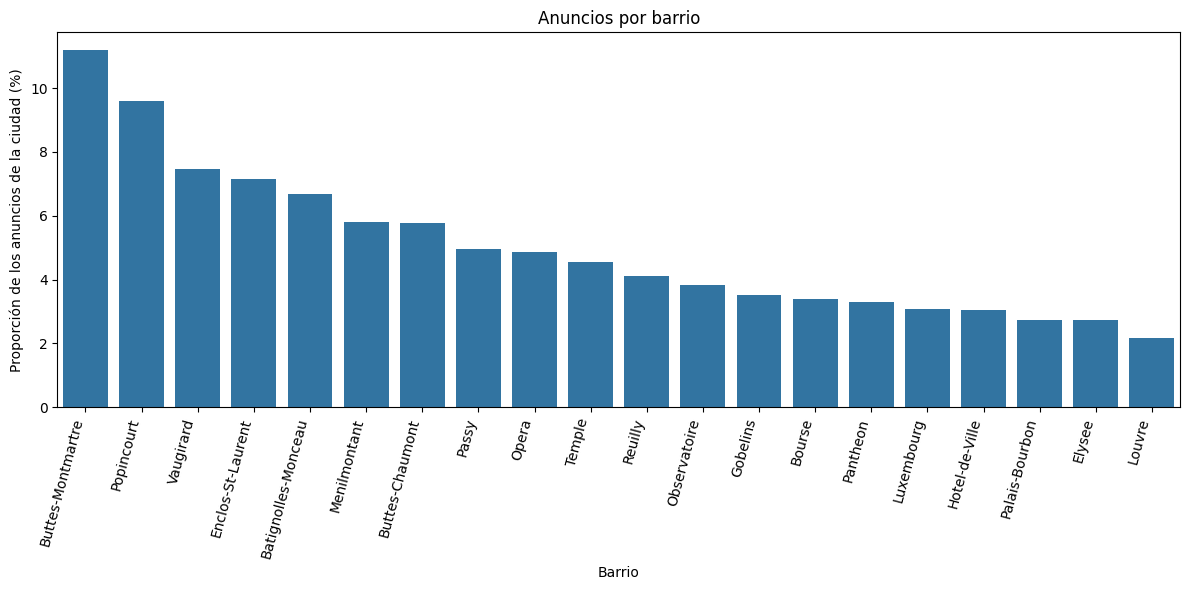

In [ ]:
pdf_nb = nb_proporcion.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf_nb,
    x="neighbourhood",
    y="share_of_city",
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Barrio")
plt.ylabel("Proporción de los anuncios de París (%)")
plt.title("Anuncios por barrio")
plt.tight_layout()
plt.show()

###**3.4. ¿Que tres ciudades presentan la mayor varianza en el precio por noche?**
**Objetivo:** Encontrar las ciudades con mayor disparidad entre los precios de los alojamientos.

**Utilidad:** Permite a los usuarios encontrar destinos que se ajusten mejor a su presupuesto, y a los host conocer que mercados son más competitivos.

In [ ]:
# Calculamos la varianza del precio por ciudad
varianza_por_ciudad = (df_raw
    .groupBy("city")
    .agg(
        variance("price").alias("price_varianza"),
        count("*").alias("listings"),
        mean("price").alias("media_price"),
        stddev("price").alias("std_dev")
    )
    .filter(col("listings") >= 100)    # solo ciudades con suficiente muestra
    .orderBy(col("price_varianza").desc())
)

# 3. Seleccionamos las 3 ciudades con mayor varianza
top3_ciudades = [row["city"] for row in varianza_por_ciudad.select("city").limit(3).collect()]
print(f"\nLas 3 ciudades con mayor varianza → {top3_ciudades}")


Las 3 ciudades con mayor varianza → ['Bangkok', 'Cape Town', 'Mexico City']


#### **3.4.2. Visualización**

/tmp/ipython-input-594086235.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pdf_top3, x="city", y="price", inner=None, palette="Set2", bw_adjust=.5, linewidth=1.5)


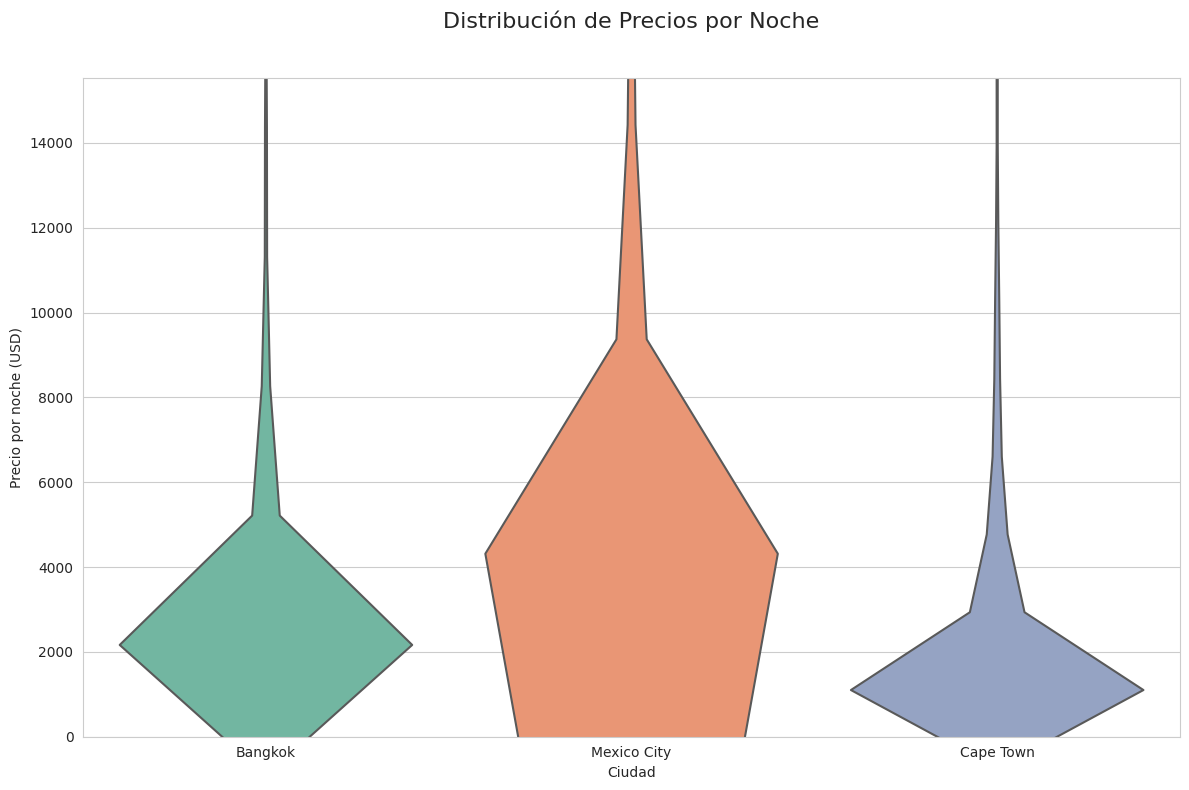

In [ ]:
df_top3 = df_raw.filter(col("city").isin(top3_ciudades)) \
                  .select("city", "price")

# Convertir a Pandas para Seaborn
pdf_top3 = df_top3.toPandas()

# Violin plot con Seaborn
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Violinplot
sns.violinplot(data=pdf_top3, x="city", y="price", inner=None, palette="Set2", bw_adjust=.5, linewidth=1.5)

plt.title("Distribución de Precios por Noche\n",
          fontsize=16, pad=20)
plt.ylabel("Precio por noche (USD)")
plt.xlabel("Ciudad")
plt.ylim(0, pdf_top3["price"].quantile(0.99))

plt.tight_layout()
plt.show()

Se ha escogido el _ViolinPlot_ de _Seaborn_ puesto que permite ver distribuciones de una métrica, en este caso el precio, para instancias distintas, en este caso ciudades.

Se aprecia como las tres ciudades agrupan la mayoría de los precios en los rangos más ecónomicos, pero depués tienen largas colas que contienen alojamientos más costosos.

###**3.5. ¿Cual ha sido el precio medio por noche a lo largo de los años?**
**Objetivo:** Identificar la evolución del precio.

**Utilidad:** Puede mostrar tendencias o efectos de la inflación que ayuden predecir rentabilidades a los arrendadores.

In [ ]:
# Cargamos el dataset con las fechas
df_reviews = spark.read.csv(
    "/kaggle/input/airbnb-listings-reviews/Airbnb Data/Reviews.csv",
    header=True,
    inferSchema=True
).select(
    col("listing_id"),
    col("date")
)
df_reviews = df_reviews.withColumn("year", year(col("date")))

# Unimos ambos
df_joined = df_reviews.join(df_raw, on="listing_id", how="inner")

# Precio medio por año
df_anual = (
    df_joined.groupBy("year")
             .agg(avg("price").alias("media_price"))
             .orderBy("year")
)

df_anual.show()

+----+------------------+
|year|       media_price|
+----+------------------+
|2008|              37.0|
|2009| 84.94782608695652|
|2010|311.96844660194176|
|2011|414.78122501199425|
|2012| 287.6337215139042|
|2013| 248.1196706385337|
|2014| 360.0881095863492|
|2015|344.63532525719506|
|2016| 350.4079050690179|
|2017| 388.6586039629439|
|2018|388.15996992549645|
|2019| 411.4971442493814|
|2020|440.60298626814455|
|2021|  470.327436853807|
+----+------------------+



#### **3.5.2. Visualización**

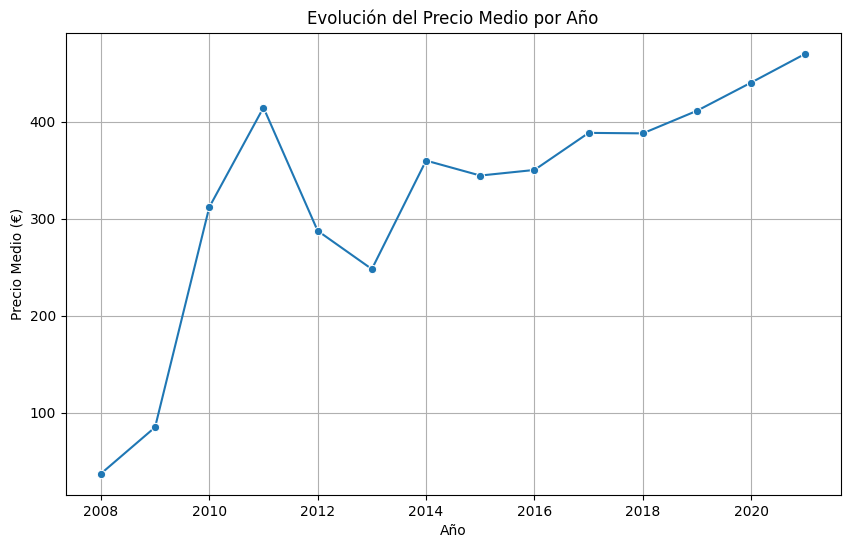

In [ ]:
pdf_anual = df_anual.toPandas().sort_values("year")

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=pdf_anual,
    x="year",
    y="media_price",
    marker="o"
)

plt.title("Evolución del Precio Medio por Año")
plt.xlabel("Año")
plt.ylabel("Precio Medio (€)")
plt.grid(True)
plt.show()